# Практика 5: Улучшение GAN — добавляем нормализацию

Обучение GAN нестабильно, поэтому добавим нормализацию (`BatchNorm2d`) в генератор, что позволит стабилизировать градиенты. В дискриминатор добавим `Dropout` для борьбы с переобучением. Переписываем архитектуру сети, экспериментируем с разными коэффициентами обучения (`lr`) и моментом (`beta1, beta2`). Визуализируем процесс генерации изображений на разных этапах, чтобы убедиться, что качество улучшается. Используем метрики оценки, такие как `FID` (Frechet Inception Distance).

In [47]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import torch_fidelity
from torchmetrics.image.fid import FrechetInceptionDistance

from tqdm.auto import tqdm

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

device

device(type='cuda')

In [ ]:
image_size = 28
channels = 1

latent_dim = 100

batch_size = 128
num_epochs = 40

lr = 0.0002
beta1 = 0.5
beta2 = 0.9

sample_every = 5
fixed_noise = torch.randn(64, latent_dim, 1, 1, device=device)

In [49]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

loader_generator = torch.Generator()
loader_generator.manual_seed(42)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    generator=loader_generator
)

print("Train samples:", len(train_dataset))

Train samples: 60000


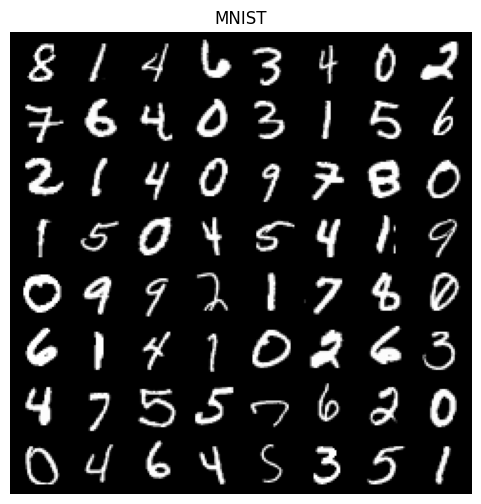

In [50]:
real_batch, _ = next(iter(train_loader))

fig, ax = plt.subplots(figsize=(6, 6))
grid = make_grid(real_batch[:64], nrow=8, normalize=True, value_range=(-1, 1))
ax.imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap="gray")
ax.axis("off")
ax.set_title("MNIST")
plt.show()

In [51]:
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 256, kernel_size=7, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.Conv2d(64, 1, kernel_size=3, stride=1, padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)

In [52]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.3),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.3)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [53]:
def init_weights(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1 or classname.find("Linear") != -1:
        if hasattr(m, "weight") and m.weight is not None:
            nn.init.normal_(m.weight.data, 0.0, 0.02)
        if hasattr(m, "bias") and m.bias is not None:
            nn.init.constant_(m.bias.data, 0)
    elif classname.find("BatchNorm") != -1:
        if hasattr(m, "weight") and m.weight is not None:
            nn.init.normal_(m.weight.data, 1.0, 0.02)
        if hasattr(m, "bias") and m.bias is not None:
            nn.init.constant_(m.bias.data, 0)

In [54]:
G = Generator(latent_dim).to(device)
D = Discriminator().to(device)

G.apply(init_weights)
D.apply(init_weights)

Discriminator(
  (features): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Dropout2d(p=0.3, inplace=False)
    (3): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Dropout2d(p=0.3, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6272, out_features=1, bias=True)
    (2): Sigmoid()
  )
)

In [55]:
fid_metric = FrechetInceptionDistance(feature=64, normalize=False).to(device)

@torch.no_grad()
def images_for_fid(x):
    x = (x + 1.0) / 2.0
    x = torch.clamp(x, 0.0, 1.0)
    x = (x * 255).to(torch.uint8)

    if x.size(1) == 1:
        x = x.repeat(1, 3, 1, 1)

    return x

In [56]:
@torch.no_grad()
def show_generated_images(generator, noise, title="Сгенерированные изображения"):
    generator.eval()
    fake_images = generator(noise).cpu()
    
    fig, ax = plt.subplots(figsize=(6, 6))
    grid = make_grid(fake_images, nrow=8, normalize=True, value_range=(-1, 1))
    ax.imshow(grid.permute(1, 2, 0).numpy(), cmap="gray")
    ax.axis("off")
    ax.set_title(title)
    plt.show()
    
    generator.train()

In [57]:
def train_loop(D, G, num_epochs):
    g_losses = []
    d_losses = []
    fid_scores = []
    history_samples = []

    loss_f = nn.BCELoss()
    optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=(beta1, beta2))
    optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=(beta1, beta2))

    progress_bar = tqdm(range(num_epochs), desc=f"Processing")
    for epoch in progress_bar:
        epoch_g_loss = 0.0
        epoch_d_loss = 0.0

        for real_images, _ in train_loader:
            real_images = real_images.to(device)
            current_batch_size = real_images.size(0)

            real_labels = torch.ones(current_batch_size, 1, device=device)
            fake_labels = torch.zeros(current_batch_size, 1, device=device)

            # 1. Обучение дискриминатора
            optimizer_D.zero_grad()

            real_preds = D(real_images)
            d_loss_real = loss_f(real_preds, real_labels)

            noise = torch.randn(current_batch_size, latent_dim, 1, 1, device=device)
            fake_images = G(noise).detach()
            fake_preds = D(fake_images)
            d_loss_fake = loss_f(fake_preds, fake_labels)

            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            optimizer_D.step()

            # 2. Обучение генератора
            optimizer_G.zero_grad()

            noise = torch.randn(current_batch_size, latent_dim, 1, 1, device=device)
            generated_images = G(noise)
            preds = D(generated_images)

            g_loss = loss_f(preds, real_labels)
            g_loss.backward()
            optimizer_G.step()

            epoch_d_loss += d_loss.item()
            epoch_g_loss += g_loss.item()

        avg_d_loss = epoch_d_loss / len(train_loader)
        avg_g_loss = epoch_g_loss / len(train_loader)

        d_losses.append(avg_d_loss)
        g_losses.append(avg_g_loss)

        # 3. Подсчёт FID за эпоху
        fid_metric.reset()

        with torch.no_grad():
            real_for_fid, _ = next(iter(train_loader))
            real_for_fid = real_for_fid.to(device)

            noise = torch.randn(real_for_fid.size(0), latent_dim, 1, 1, device=device)
            fake_for_fid = G(noise)

            fid_metric.update(images_for_fid(real_for_fid), real=True)
            fid_metric.update(images_for_fid(fake_for_fid), real=False)

            fid_value = float(fid_metric.compute().item())

        fid_scores.append(fid_value)

        progress_bar.set_postfix({
            "D Loss": f"{avg_d_loss:.4f}",
            "G Loss" : f"{avg_g_loss:.4f}",
            "FID" : f"{fid_value:.4f}"
        })

        if (epoch + 1) % sample_every == 0 or epoch == 0:
            with torch.no_grad():
                samples = G(fixed_noise).cpu()
                history_samples.append((epoch + 1, samples))
            show_generated_images(G, fixed_noise, title=f"Epoch {epoch + 1}")
    
    return g_losses, d_losses, fid_scores, history_samples

Processing:   0%|          | 0/40 [01:06<?, ?it/s, D Loss=1.3761, G Loss=0.6703, FID=0.9060]

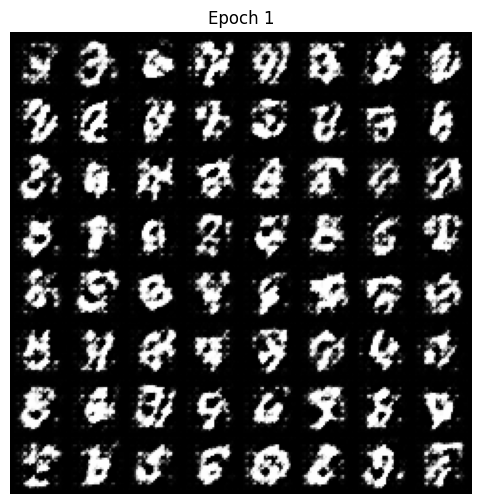

Processing:  10%|█         | 4/40 [05:35<40:12, 67.02s/it, D Loss=1.3767, G Loss=0.7091, FID=0.1319]

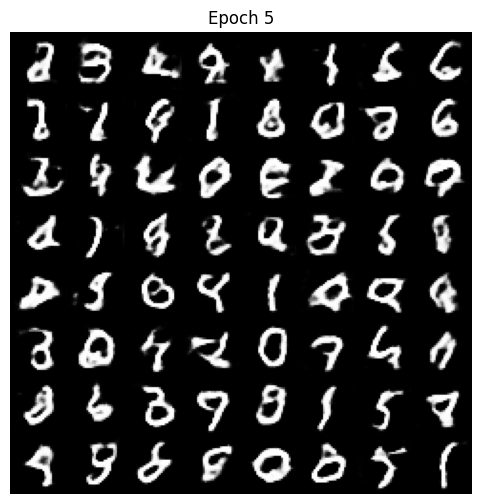

Processing:  22%|██▎       | 9/40 [11:12<34:47, 67.33s/it, D Loss=1.3790, G Loss=0.7097, FID=0.0599]

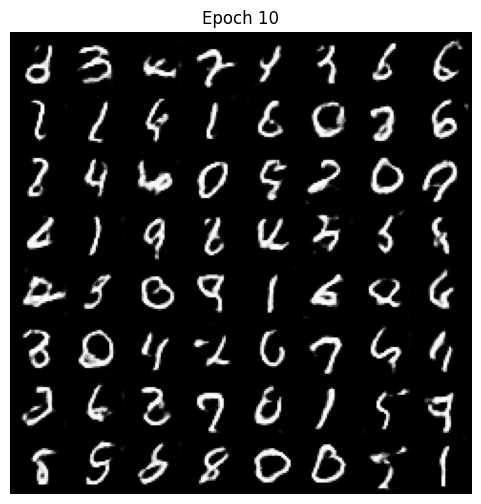

Processing:  35%|███▌      | 14/40 [16:53<29:15, 67.53s/it, D Loss=1.3800, G Loss=0.7091, FID=0.1662]

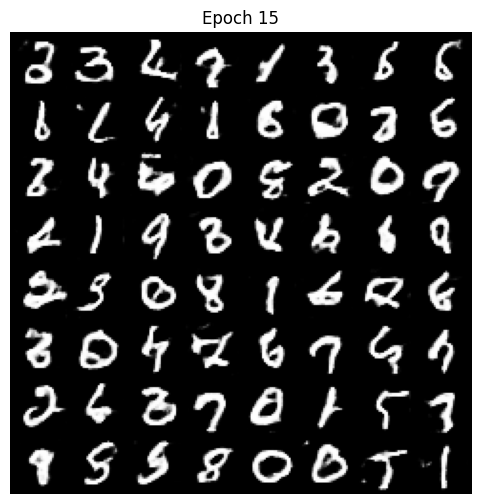

Processing:  48%|████▊     | 19/40 [22:40<24:03, 68.75s/it, D Loss=1.3801, G Loss=0.7071, FID=0.0444]

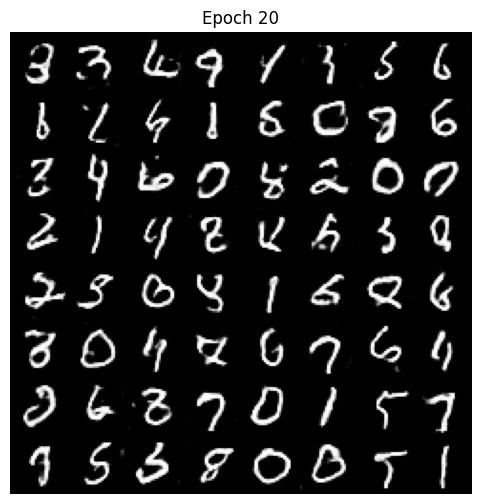

Processing:  60%|██████    | 24/40 [28:34<18:48, 70.50s/it, D Loss=1.3807, G Loss=0.7088, FID=0.0167]

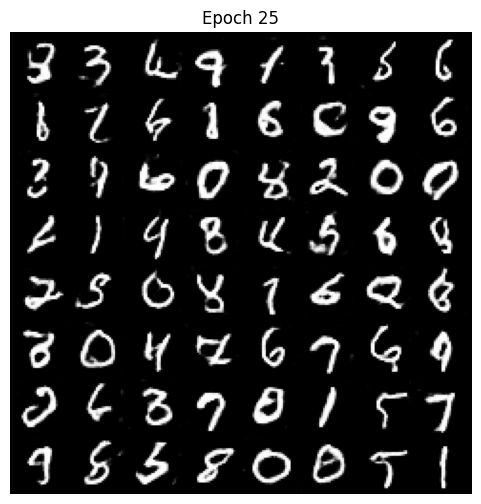

Processing:  72%|███████▎  | 29/40 [34:22<12:47, 69.81s/it, D Loss=1.3810, G Loss=0.7067, FID=0.0394]

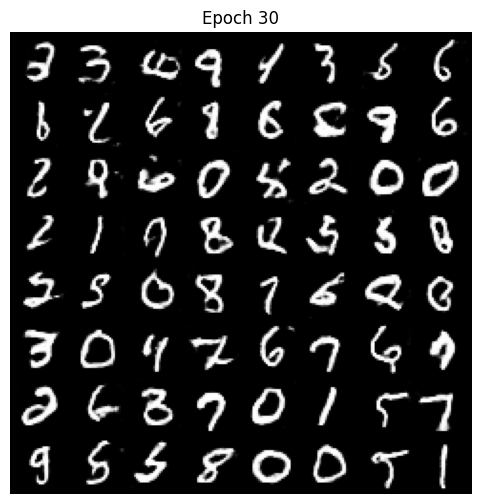

Processing:  85%|████████▌ | 34/40 [40:11<06:59, 69.86s/it, D Loss=1.3811, G Loss=0.7078, FID=0.0238]

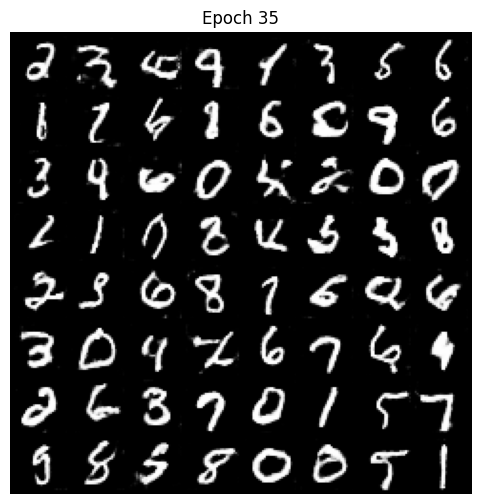

Processing:  98%|█████████▊| 39/40 [46:00<01:09, 69.69s/it, D Loss=1.3816, G Loss=0.7066, FID=0.0149]

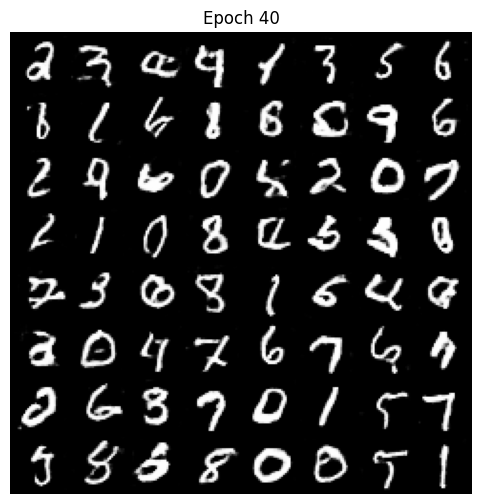

Processing: 100%|██████████| 40/40 [46:01<00:00, 69.03s/it, D Loss=1.3816, G Loss=0.7066, FID=0.0149]


In [58]:
g_losses, d_losses, fid_scores, history_samples = train_loop(D= D, G= G, num_epochs= num_epochs)

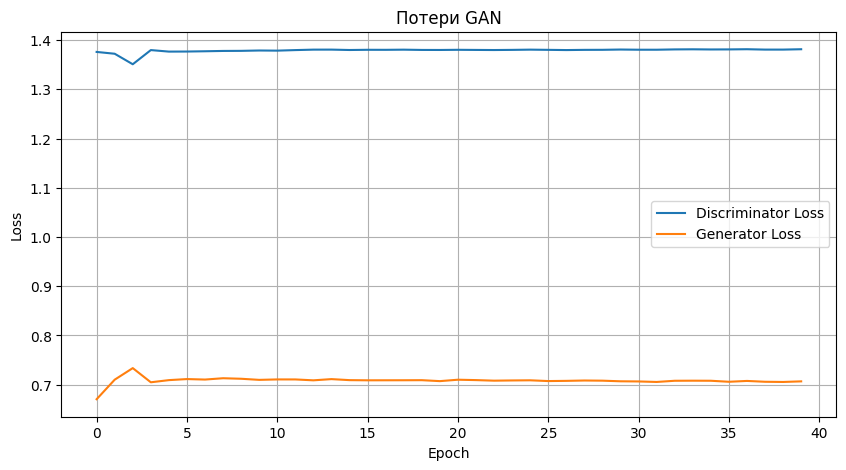

In [62]:
plt.figure(figsize=(10, 5))
plt.plot(d_losses, label="Discriminator Loss")
plt.plot(g_losses, label="Generator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Потери GAN")
plt.legend()
plt.grid(True)
plt.show()

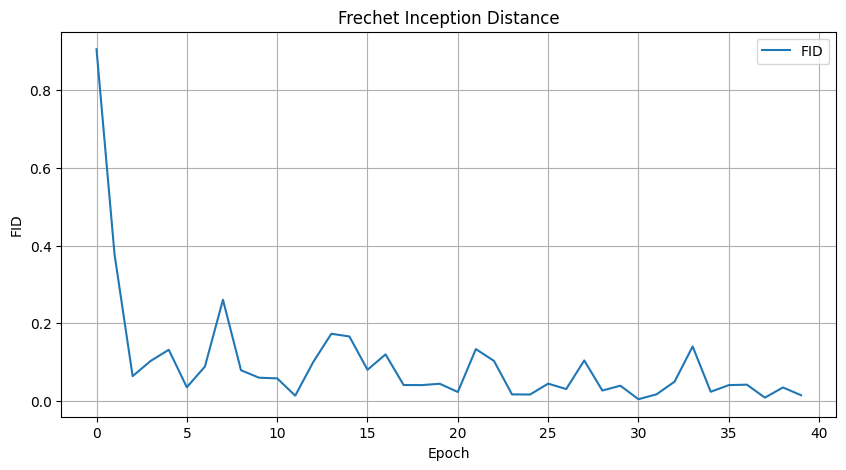

In [63]:
plt.figure(figsize=(10, 5))
plt.plot(fid_scores, label="FID")
plt.xlabel("Epoch")
plt.ylabel("FID")
plt.title("Frechet Inception Distance")
plt.legend()
plt.grid(True)
plt.show()

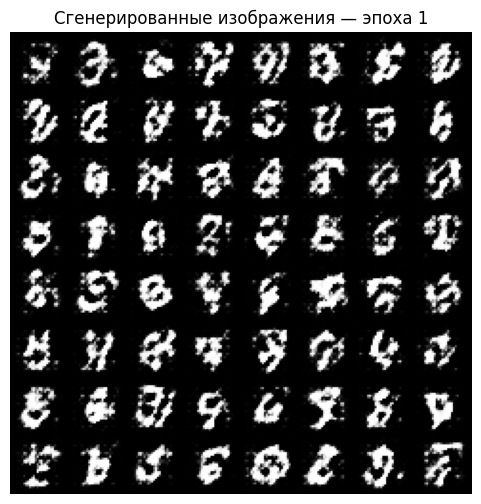

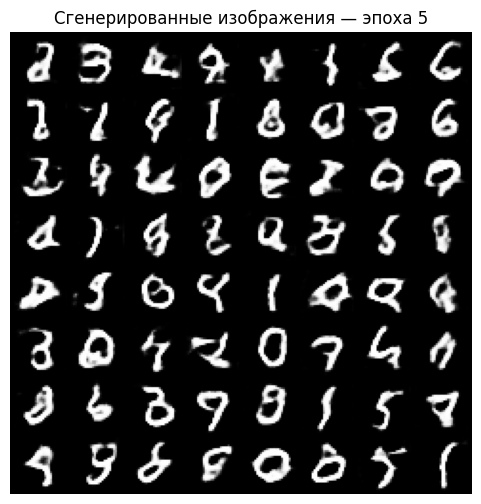

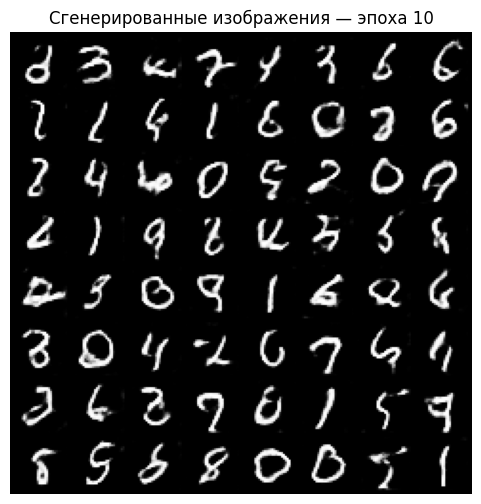

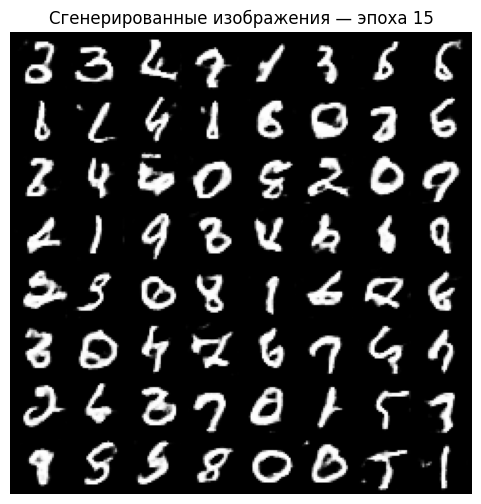

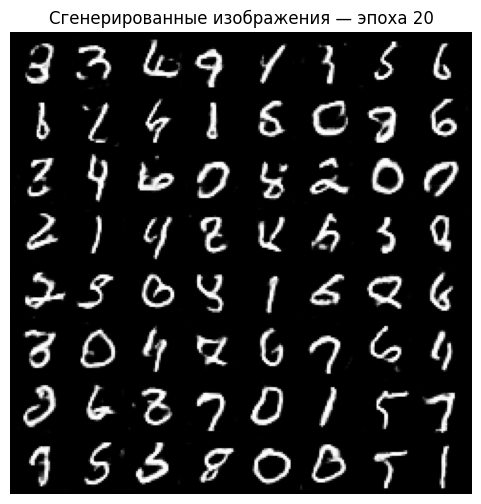

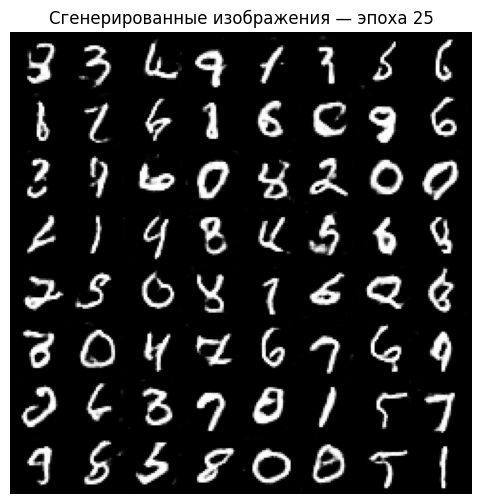

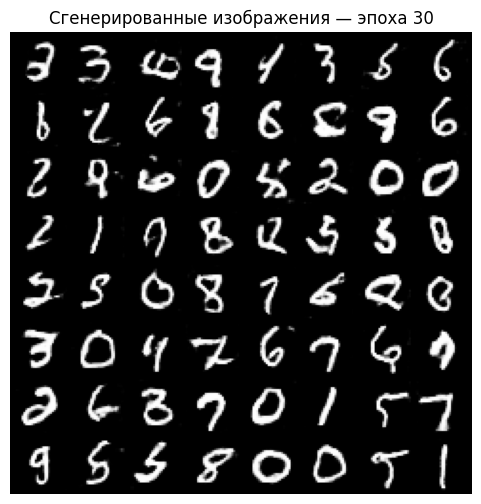

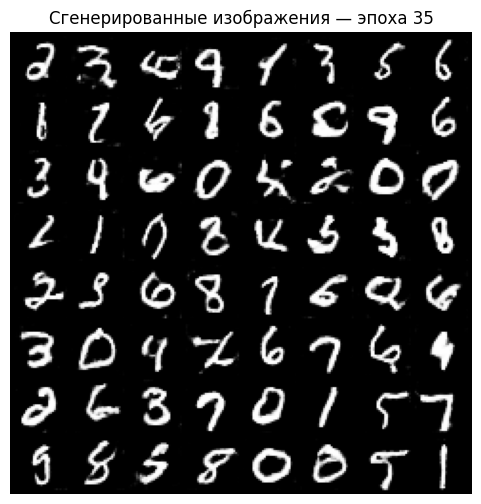

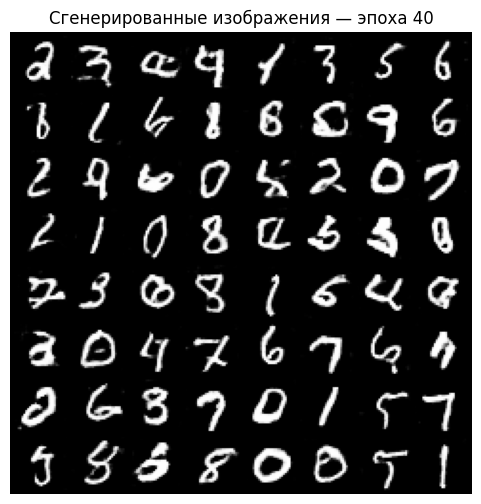

In [64]:
for epoch_num, samples in history_samples:
    fig, ax = plt.subplots(figsize=(6, 6))
    grid = make_grid(samples[:64], nrow=8, normalize=True, value_range=(-1, 1))
    ax.imshow(grid.permute(1, 2, 0).numpy(), cmap="gray")
    ax.axis("off")
    ax.set_title(f"Сгенерированные изображения — эпоха {epoch_num}")
    plt.show()

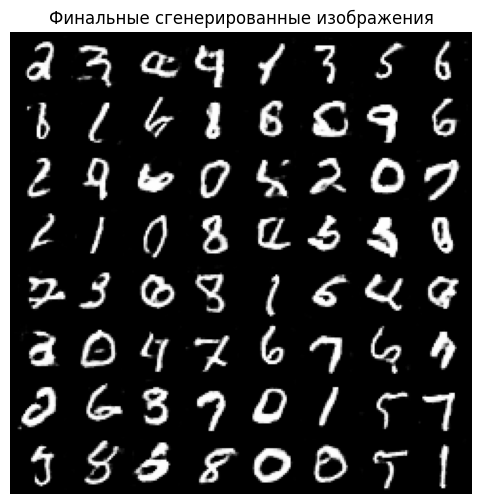

In [65]:
show_generated_images(G, fixed_noise, title="Финальные сгенерированные изображения")